In [20]:
import glob
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pressuredata 디렉토리의 모든 CSV 파일 찾기
csv_files = sorted(glob.glob('*.csv'))
print(f"발견된 CSV 파일 수: {len(csv_files)}")
for f in csv_files:
    print(f"- {f}")

발견된 CSV 파일 수: 6
- Carotid_artery1.csv
- Carotid_artery2.csv
- diaphragm.csv
- ulnar_artery1.csv
- ulnar_artery2.csv
- wrist_motion.csv


Carotid_artery1.csv: 2367 points plotted (removed outliers: 1)
Carotid_artery2.csv: 1537 points plotted (removed outliers: 1)
diaphragm.csv: 3053 points plotted (removed outliers: 1)
ulnar_artery1.csv: 3014 points plotted (removed outliers: 37)
ulnar_artery2.csv: 1526 points plotted (removed outliers: 177)
wrist_motion.csv: 3162 points plotted (removed outliers: 1)


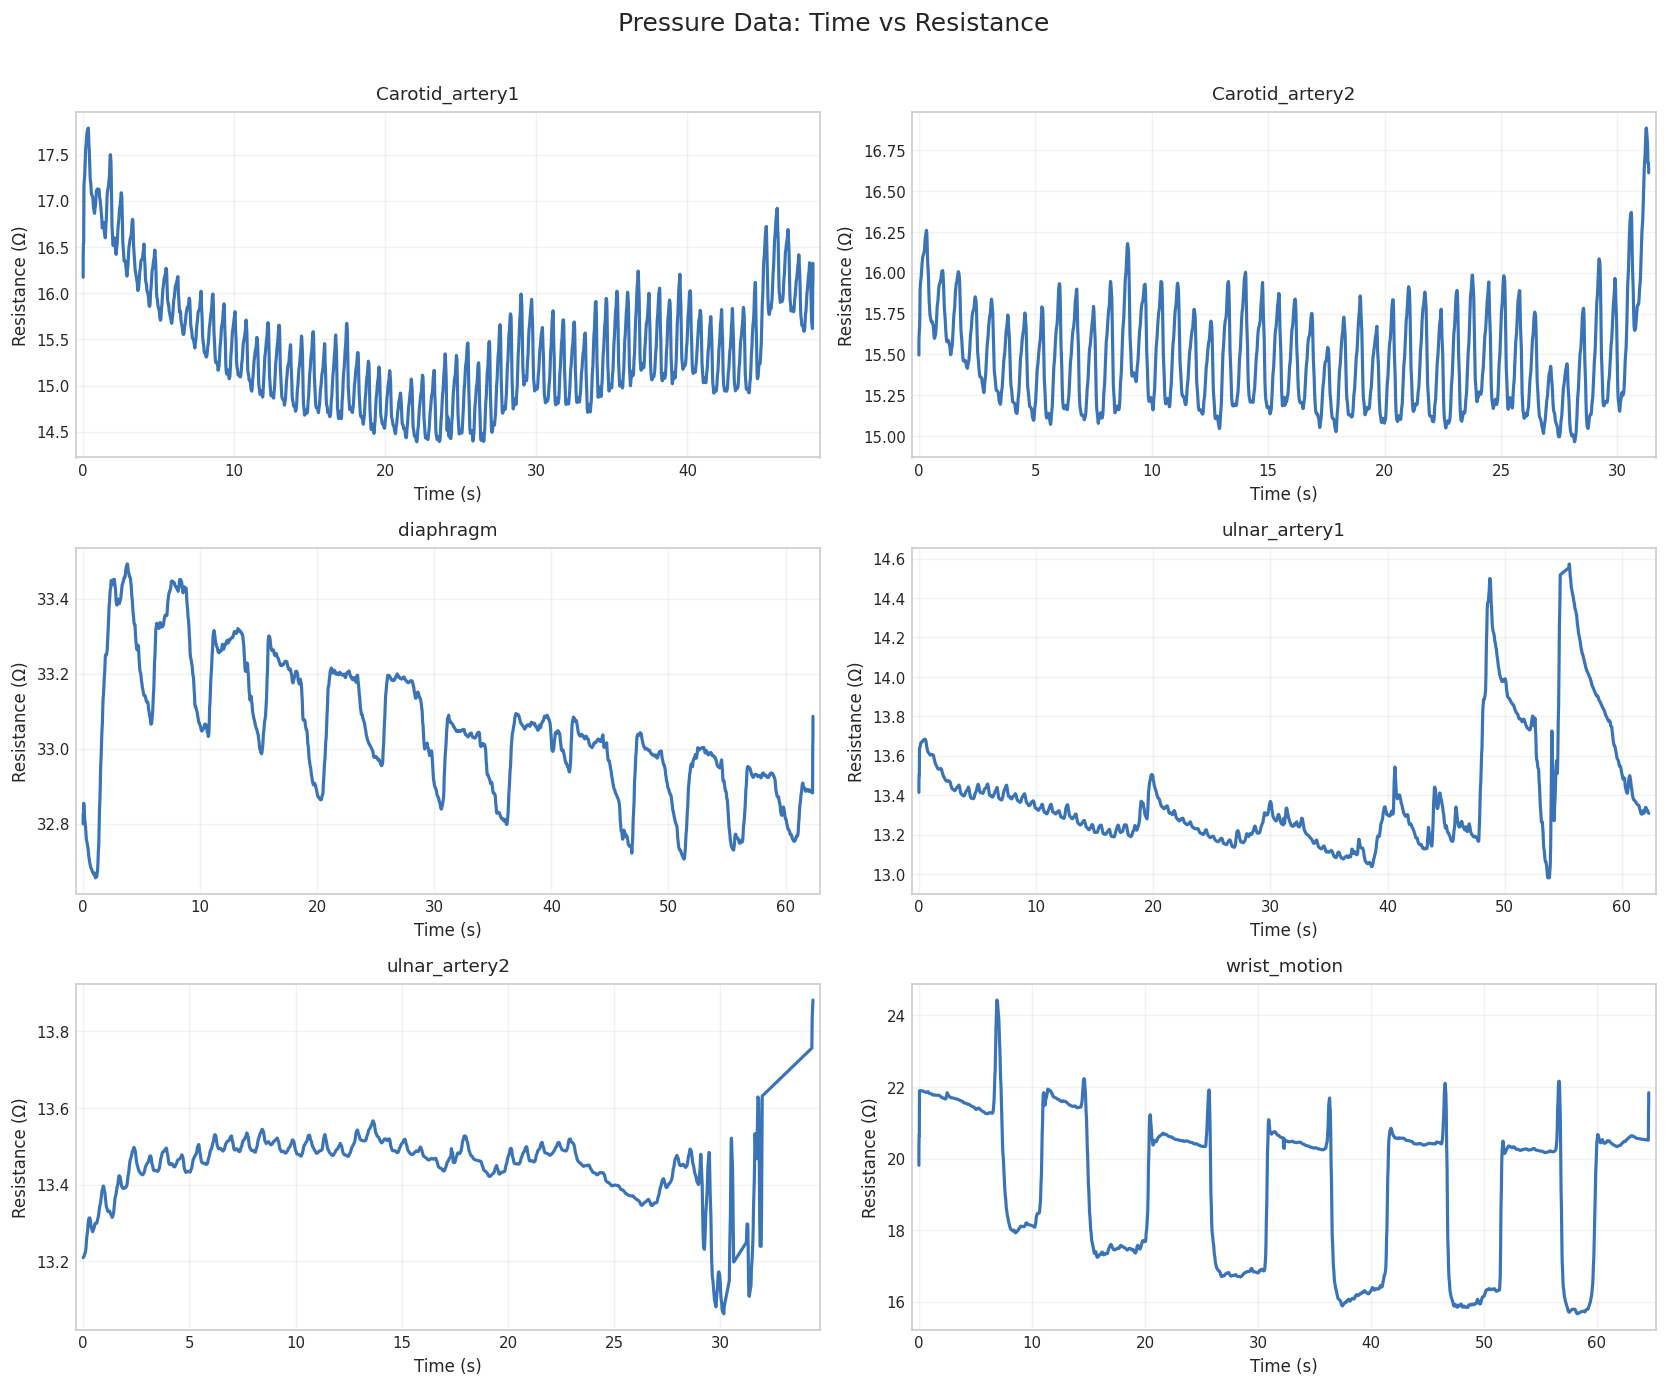

In [21]:
# 각 CSV 파일을 보기 좋게 플롯 (X: Time, Y: Resistance)
plt.style.use('seaborn-v0_8-whitegrid')

n_files = len(csv_files)
if n_files == 0:
    raise RuntimeError('현재 디렉토리에 CSV 파일이 없습니다.')

n_cols = 2 if n_files > 1 else 1
n_rows = math.ceil(n_files / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3.8 * n_rows), dpi=120)
axes = np.atleast_1d(axes).ravel()

for idx, csv_file in enumerate(csv_files):
    df = pd.read_csv(csv_file, skiprows=21)  # 장비 메타데이터 헤더 건너뛰기
    df.columns = df.columns.str.strip()

    time_candidates = [c for c in df.columns if 'Time' in c]
    resistance_candidates = [c for c in df.columns if 'Resistance' in c]

    if not time_candidates or not resistance_candidates:
        print(f"[스킵] {csv_file}: Time/Resistance 컬럼을 찾지 못했습니다.")
        continue

    time_col = time_candidates[0]
    resistance_col = resistance_candidates[0]

    # 문자열로 읽힌 숫자를 안전하게 실수형으로 변환
    plot_df = df[[time_col, resistance_col]].copy()
    plot_df[time_col] = pd.to_numeric(plot_df[time_col], errors='coerce')
    plot_df[resistance_col] = pd.to_numeric(plot_df[resistance_col], errors='coerce')
    plot_df = plot_df.dropna().sort_values(time_col)

    # 극단값(측정 글리치) 제거: MAD 기반 로버스트 필터
    res = plot_df[resistance_col]
    median = res.median()
    mad = np.median(np.abs(res - median))
    if mad > 0:
        robust_z = 0.6745 * (res - median) / mad
        filtered_df = plot_df[np.abs(robust_z) < 8].copy()
    else:
        q1, q3 = res.quantile(0.25), res.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 3 * iqr, q3 + 3 * iqr
        filtered_df = plot_df[(res >= low) & (res <= high)].copy()

    # 약한 스무딩으로 가독성 향상
    filtered_df['res_smooth'] = filtered_df[resistance_col].rolling(
        window=5, center=True, min_periods=1
    ).mean()

    ax = axes[idx]
    ax.plot(
        filtered_df[time_col],
        filtered_df['res_smooth'],
        color='#2F6DB3',
        linewidth=1.9,
        alpha=0.95,
    )

    ax.set_title(csv_file.replace('.csv', ''), fontsize=11, pad=8)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Resistance (Ω)', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.margins(x=0.01, y=0.05)
    ax.grid(True, alpha=0.25)

    removed = len(plot_df) - len(filtered_df)
    print(f"{csv_file}: {len(filtered_df)} points plotted (removed outliers: {removed})")

# 남는 축 제거 (CSV 개수와 subplot 개수가 다를 때)
for j in range(n_files, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Pressure Data: Time vs Resistance', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Carotid_artery1.csv: 736 points
Carotid_artery2.csv: 736 points
ulnar_artery1.csv: 736 points
ulnar_artery2.csv: 735 points
diaphragm.csv: 3053 points


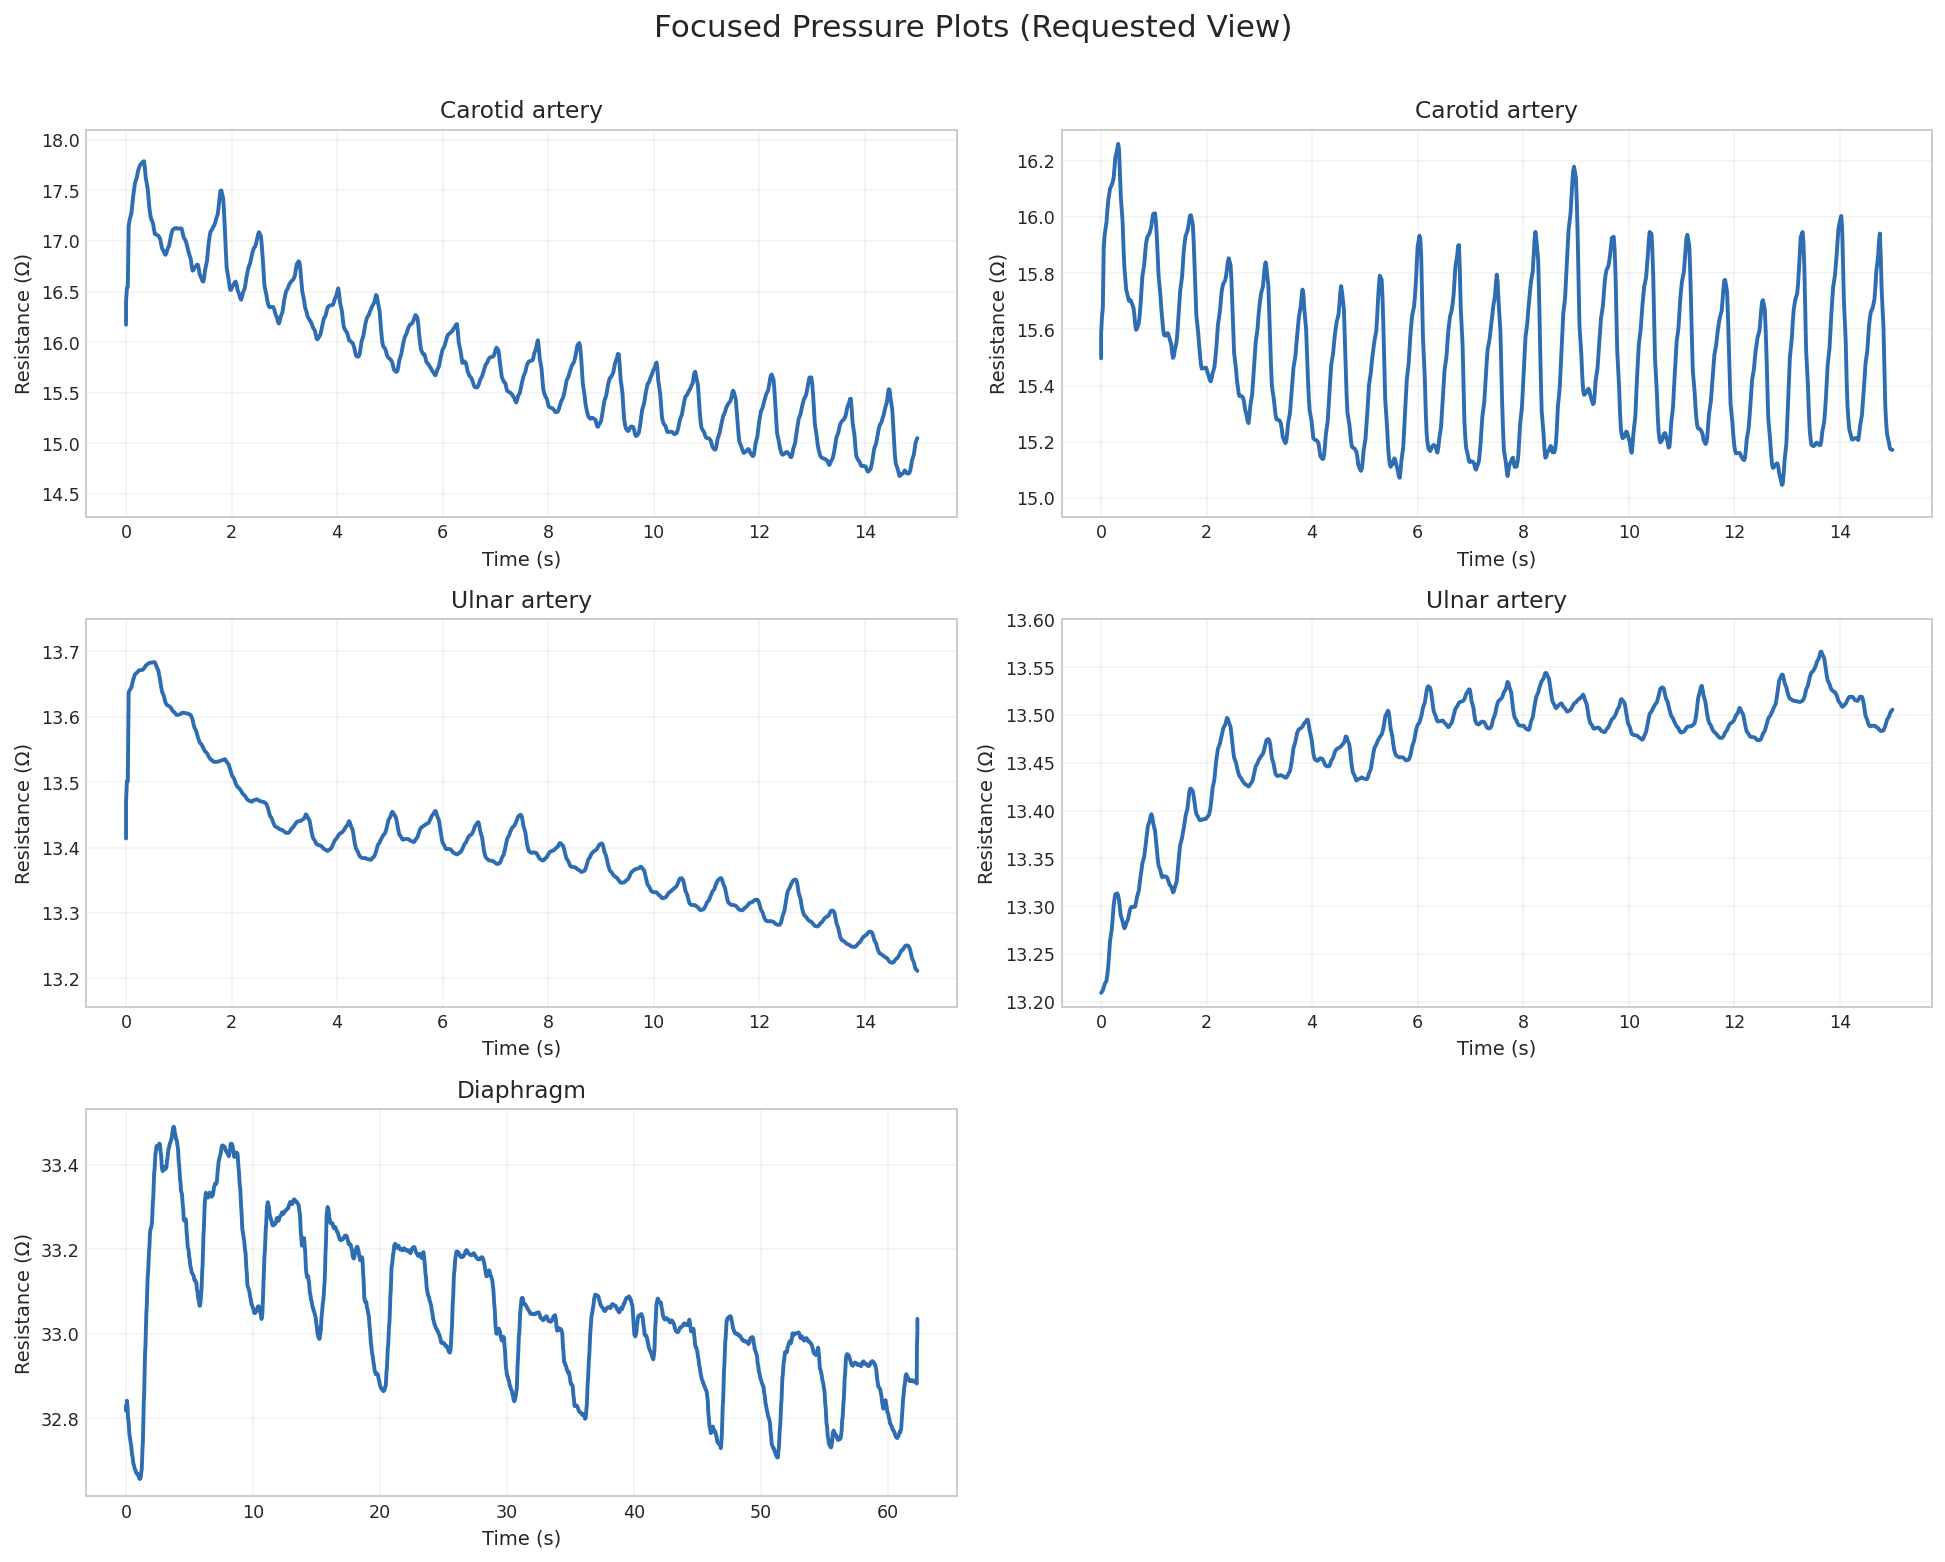

In [ ]:
# 요청 반영 추가 시각화
# - Carotid/ulnar: 0~15초 구간만 확대
# - diaphragm: 시작부 스파이크 제거
# - diaphragm도 다른 그래프와 동일한 크기로 표시
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(14, 11), dpi=140)
axes = np.atleast_1d(axes).ravel()
ax_map = {
    'car1': axes[0],
    'car2': axes[1],
    'ul1': axes[2],
    'ul2': axes[3],
    'dia': axes[4],
}

plot_specs = {
    'Carotid_artery1.csv': {'ax': 'car1', 'title': 'Carotid artery', 'window': (0, 15), 'smooth': 5},
    'Carotid_artery2.csv': {'ax': 'car2', 'title': 'Carotid artery', 'window': (0, 15), 'smooth': 5},
    'ulnar_artery1.csv': {'ax': 'ul1', 'title': 'Ulnar artery', 'window': (0, 15), 'smooth': 5},
    'ulnar_artery2.csv': {'ax': 'ul2', 'title': 'Ulnar artery', 'window': (0, 15), 'smooth': 5},
    'diaphragm.csv': {'ax': 'dia', 'title': 'Diaphragm', 'window': None, 'smooth': 7},
}

for file_name, spec in plot_specs.items():
    if file_name not in csv_files:
        print(f"[스킵] 파일 없음: {file_name}")
        continue

    df = pd.read_csv(file_name, skiprows=21)
    df.columns = df.columns.str.strip()

    time_col = [c for c in df.columns if 'Time' in c][0]
    resistance_col = [c for c in df.columns if 'Resistance' in c][0]

    plot_df = df[[time_col, resistance_col]].copy()
    plot_df[time_col] = pd.to_numeric(plot_df[time_col], errors='coerce')
    plot_df[resistance_col] = pd.to_numeric(plot_df[resistance_col], errors='coerce')
    plot_df = plot_df.dropna().sort_values(time_col)

    # 공통 로버스트 이상치 제거
    res = plot_df[resistance_col]
    med = res.median()
    mad = np.median(np.abs(res - med))
    if mad > 0:
        robust_z = 0.6745 * (res - med) / mad
        plot_df = plot_df[np.abs(robust_z) < 8].copy()

    # diaphragm 시작부 글리치 제거
    if file_name == 'diaphragm.csv':
        stable = plot_df[plot_df[time_col] >= 2.0][resistance_col]
        if len(stable) > 10:
            s_med = stable.median()
            s_mad = np.median(np.abs(stable - s_med))
            threshold = (6 * s_mad) if s_mad > 0 else 0.2
            early_mask = plot_df[time_col] <= 2.0
            spike_mask = early_mask & (np.abs(plot_df[resistance_col] - s_med) > threshold)
            plot_df = plot_df[~spike_mask].copy()

    # 파일별 시간 구간 적용
    if spec['window'] is not None:
        t0, t1 = spec['window']
        plot_df = plot_df[(plot_df[time_col] >= t0) & (plot_df[time_col] <= t1)].copy()

    # 가독성 향상을 위한 약한 스무딩
    plot_df['res_smooth'] = plot_df[resistance_col].rolling(
        window=spec['smooth'], center=True, min_periods=1
    ).mean()

    ax = ax_map[spec['ax']]
    ax.plot(plot_df[time_col], plot_df['res_smooth'], color='#2F6DB3', linewidth=2.0)
    ax.set_title(spec['title'], fontsize=12)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Resistance (Ω)', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(True, alpha=0.25)

    # 확대 구간은 y축도 조금 타이트하게 설정
    if spec['window'] is not None and len(plot_df) > 20:
        y_lo, y_hi = plot_df['res_smooth'].quantile([0.01, 0.99])
        pad = max((y_hi - y_lo) * 0.15, 0.02)
        ax.set_ylim(y_lo - pad, y_hi + pad)

    print(f"{file_name}: {len(plot_df)} points")

# 사용하지 않는 마지막 축은 숨김
axes[5].axis('off')

fig.suptitle('Focused Pressure Plots (Requested View)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()